In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display all columns when we look at the data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load the CSV file
df = pd.read_csv('../data/raw/complaints_raw.csv')

print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())

Number of rows: 162421
Number of columns: 3

Column names:
['Unnamed: 0', 'product', 'narrative']


In [8]:
# Display the first 5 rows
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume or...
1,1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria ...
2,2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account see court hearing several different government agency reporti...
3,3,credit_reporting,payment history missing credit report specialized loan servicing sl made mistake put account forbearance without authorization knowledge matter fact automatic payment setup month monthly mortgage ...
4,4,credit_reporting,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fact automatic payment setup month monthly mortgage paid full noticed issue accoun...


In [11]:
# How many complaints actually have a text narrative?
total = len(df)
with_text = df['narrative'].notna().sum()

print(f"Total complaints: {total}")
print(f"Complaints WITH text: {with_text}")
print(f"Percentage with text: {with_text/total*100:.1f}%")

Total complaints: 162421
Complaints WITH text: 162411
Percentage with text: 100.0%


In [13]:
# Keep only rows that have a complaint text
df_text = df[df['narrative'].notna()].copy()
print(f"Complaints with text: {len(df_text)}")

# Look at the distribution of products
print("\nTop 10 products:")
print(df_text['product'].value_counts().head(10))

Complaints with text: 162411

Top 10 products:
product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


In [14]:
# Look at the most common issues
print("Top 20 issues:")
print(df_text['Issue'].value_counts().head(20))

Top 20 issues:


KeyError: 'Issue'

Average length: 80 words
Median length: 50 words
Min length: 1 words
Max length: 2685 words


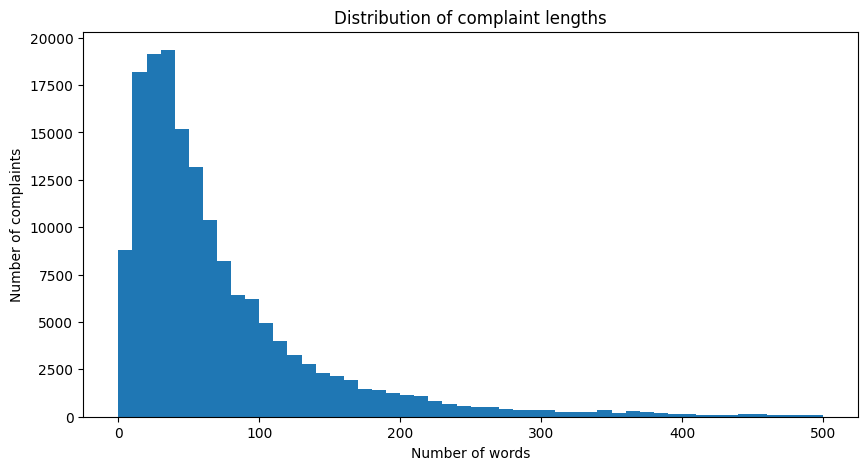

In [15]:
# How long are the complaints?
df_text['text_length'] = df_text['narrative'].str.split().str.len()

print(f"Average length: {df_text['text_length'].mean():.0f} words")
print(f"Median length: {df_text['text_length'].median():.0f} words")
print(f"Min length: {df_text['text_length'].min()} words")
print(f"Max length: {df_text['text_length'].max()} words")

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(df_text['text_length'], bins=50, range=(0, 500))
plt.xlabel('Number of words')
plt.ylabel('Number of complaints')
plt.title('Distribution of complaint lengths')
plt.show()

In [16]:
# Read a few examples to understand the data
for i in range(3):
    print(f"=== Complaint {i+1} ===")
    print(f"Product: {df_text.iloc[i]['product']}")
    print(f"Text: {df_text.iloc[i]['narrative'][:300]}...")
    print()

=== Complaint 1 ===
Product: credit_card
Text: purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing r...

=== Complaint 2 ===
Product: credit_card
Text: forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria secret original credit comenity bank lower limit began charge overage fee along late fee began pay close...

=== Complaint 3 ===
Product: retail_banking
Text: forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account see court hearing several different government agency reporting well including branch put open account numerous